In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import os
import re
from pathlib import Path

if os.path.basename(os.getcwd()) == "plots":
    os.chdir("..")

import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from coffea.util import load
from plots import hep_plot as hplot
from plots.hep_plot import CMS_COLORS
import hist

hplot.setup(era="2024")

In [30]:
# ── Load samples ──────────────────────────────────────────────────────────────
coffea_dir = Path("./outputs/dy")
data_eras = ["2024C", "2024D", "2024E", "2024F", "2024G", "2024H"]


def _qcd_pt_sort_key(path):
    match = re.search(r"(?:QCD_)?PT-(\d+)to(\d+|Inf)", path.name)
    if match is None:
        return (float("inf"), float("inf"), path.name)
    low = int(match.group(1))
    high = float("inf") if match.group(2) == "Inf" else int(match.group(2))
    return (low, high, path.name)


def _qcd_pt_label(path):
    match = re.search(r"(?:QCD_)?PT-(\d+)to(\d+|Inf)", path.name)
    if match is None:
        return path.stem
    return f"QCD {match.group(1)}-{match.group(2)}"


def _load_components(paths):
    paths = sorted(paths, key=_qcd_pt_sort_key)
    if not paths:
        raise FileNotFoundError(
            f"No QCD pT-bin files found in {coffea_dir} matching the 2024 QCD pattern"
        )
    return [(_qcd_pt_label(path), load(path)) for path in paths]


ttbar_output = load(coffea_dir / "TTbar_2024_inclusive_noSyst.coffea")
qcd_paths = list(coffea_dir.glob("QCD_2024*_PT-*to*_noSyst.coffea"))
qcd_components = _load_components(qcd_paths)
data_outputs = [load(f"./outputs/dy/data_{era}_noSyst.coffea") for era in data_eras]

print("Loaded:")
print("  TTbar")
print("  QCD:", ", ".join(label for label, _ in qcd_components))
print("  Data:", ", ".join(data_eras))

Loaded:
  TTbar
  QCD: QCD 470-600, QCD 600-800, QCD 800-1000, QCD 1000-1500, QCD 1500-2000, QCD 2000-2500, QCD 2500-3000
  Data: 2024C, 2024D, 2024E, 2024F, 2024G, 2024H


In [31]:
print(qcd_paths)

[PosixPath('outputs/dy/QCD_2024_QCD_PT-2000to2500_noSyst.coffea'), PosixPath('outputs/dy/QCD_2024_QCD_PT-1000to1500_noSyst.coffea'), PosixPath('outputs/dy/QCD_2024_QCD_PT-1500to2000_noSyst.coffea'), PosixPath('outputs/dy/QCD_2024_QCD_PT-470to600_noSyst.coffea'), PosixPath('outputs/dy/QCD_2024_QCD_PT-2500to3000_noSyst.coffea'), PosixPath('outputs/dy/QCD_2024_QCD_PT-800to1000_noSyst.coffea'), PosixPath('outputs/dy/QCD_2024_QCD_PT-600to800_noSyst.coffea')]


In [32]:
# ── Small plotting helpers ────────────────────────────────────────────────────
def _plot_axis_name(h):
    axis_names = [axis.name for axis in h.axes]
    candidates = [name for name in axis_names if name not in {"systematic", "anacat"}]
    if len(candidates) != 1:
        raise ValueError(f"Could not identify one plot axis from {axis_names}")
    return candidates[0]


def get_hist(output, var, anacat_id, syst="nominal"):
    h = output[var][syst, ...]
    axis_name = _plot_axis_name(h)
    return h[anacat_id, :].project(axis_name)


def sum_hists(hists):
    if not hists:
        raise ValueError("Need at least one histogram to sum")
    result = hists[0]
    for h in hists[1:]:
        result = result + h
    return result


def scaled_qcd_hists(var, anacat_id, h_data, h_ttbar):
    """Scale QCD so integral(QCD) = integral(data) - integral(TTbar)."""
    raw_hists = [get_hist(output, var, anacat_id) for _, output in qcd_components]
    raw_total = sum_hists(raw_hists).sum().value
    target = h_data.sum().value - h_ttbar.sum().value
    scale = max(target, 0.0) / raw_total if raw_total > 0 else 0.0
    if target < 0:
        print(
            f"Warning: data - TTbar is negative for {var}, anacat={anacat_id}; "
            "setting QCD scale to 0."
        )
    return [scale * h for h in raw_hists], scale, target


def draw_uncertainty_band(ax, h, *, label, density=False, hatch="///", zorder=2):
    variances = h.variances()
    if variances is None:
        return

    values = h.values()
    edges = h.axes[0].edges
    errors = np.sqrt(np.clip(variances, 0.0, None))

    if density:
        area = np.sum(values * np.diff(edges))
        if area > 0:
            values = values / area
            errors = errors / area

    lower = np.clip(values - errors, 0.0, None)
    upper = values + errors
    ax.fill_between(
        edges,
        np.r_[lower, lower[-1]],
        np.r_[upper, upper[-1]],
        step="post",
        facecolor="none",
        edgecolor="black",
        hatch=hatch,
        linewidth=0.0,
        label=label,
        zorder=zorder,
    )


def qcd_colors(n):
    cmap = plt.get_cmap("tab20")
    if hasattr(cmap, "colors"):
        color_order = list(range(0, cmap.N, 2)) + list(range(1, cmap.N, 2))
        return [cmap(color_order[i % cmap.N]) for i in range(n)]
    return [cmap(0.35 + 0.5 * i / max(n - 1, 1)) for i in range(n)]


def sort_legend_entries(handles, labels):
    def key(item):
        _, label = item
        qcd_match = re.match(r"QCD (\d+)-(\d+|Inf)$", label)
        if label == r"$t\bar{t}$":
            return (0, 0)
        if qcd_match:
            return (1, int(qcd_match.group(1)))
        if label == "MC unc.":
            return (2, 0)
        if label == "Data":
            return (3, 0)
        return (4, label)

    entries = sorted(zip(handles, labels), key=key)
    return zip(*entries) if entries else ([], [])


def get_data_hist(var, anacat_id, syst="nominal"):
    return sum_hists([get_hist(output, var, anacat_id, syst) for output in data_outputs])

In [33]:
# Inspect available keys and categories (use any sample as reference)
ref = ttbar_output
print("Histogram keys:", list(ref.keys()))
print("Categories:", ref["analysisCategories"])

Histogram keys: ['ttbarmass', 'mtt_unwgt', 'mtt_vs_mt', 'numerator', 'denominator', 'jetmass', 'jetmsd', 'jetdy', 'chi', 'jetmass1', 'jetmsd1', 'dR_min_jet2', 'jet0_pt', 'jet0_eta', 'jet0_phi', 'jet0_rapidity', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_rapidity', 'gen_mt', 'gen_mttbar', 'jet0_gen_dr', 'jet1_gen_dr', 'jet_mass_resolution', 'gen_jetmsd_reco_jetmsd', 'ht', 'cutflow', 'weights', 'systematics', 'event_list', 'truthstudy', 'sample_metadata', 'normalization', 'cutflow_scaled', 'analysisCategories']
Categories: {0: 'atcen', 1: 'atfwd', 2: '2tcen', 3: '2tfwd'}


## Per-sample distributions — central and forward categories

Each row: one variable.
Left column: central (`|Δy| < 1`), right column: forward (`|Δy| > 1`).

TTbar keeps its MC normalization. QCD pT bins keep their relative shapes, but their total
normalization is set from data:

`sum(QCD) = sum(data) - sum(TTbar)`

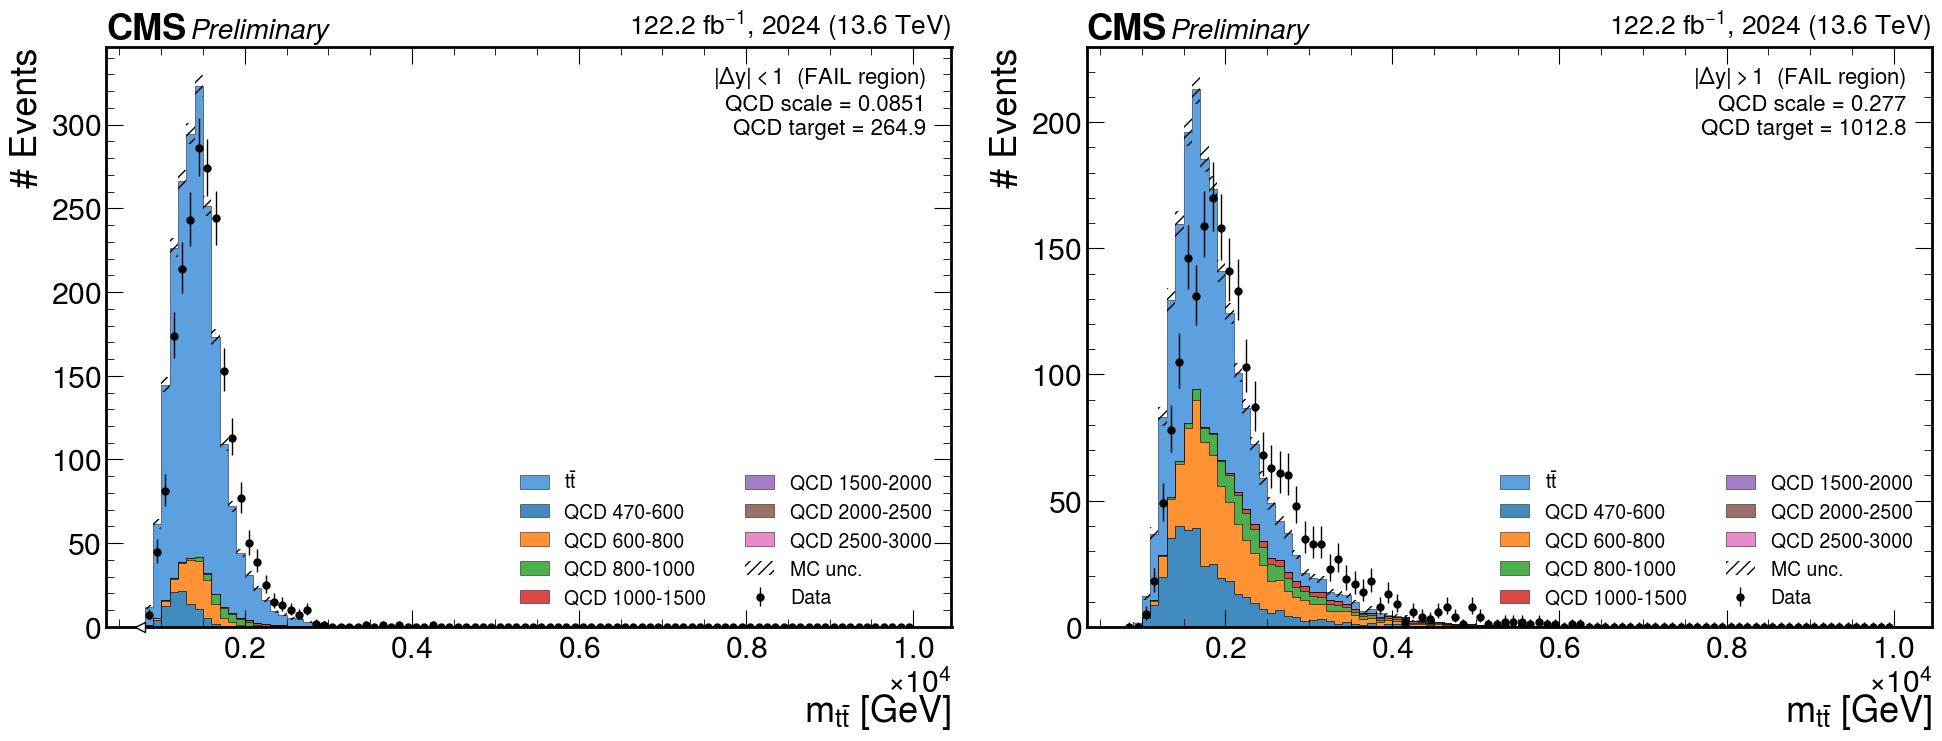

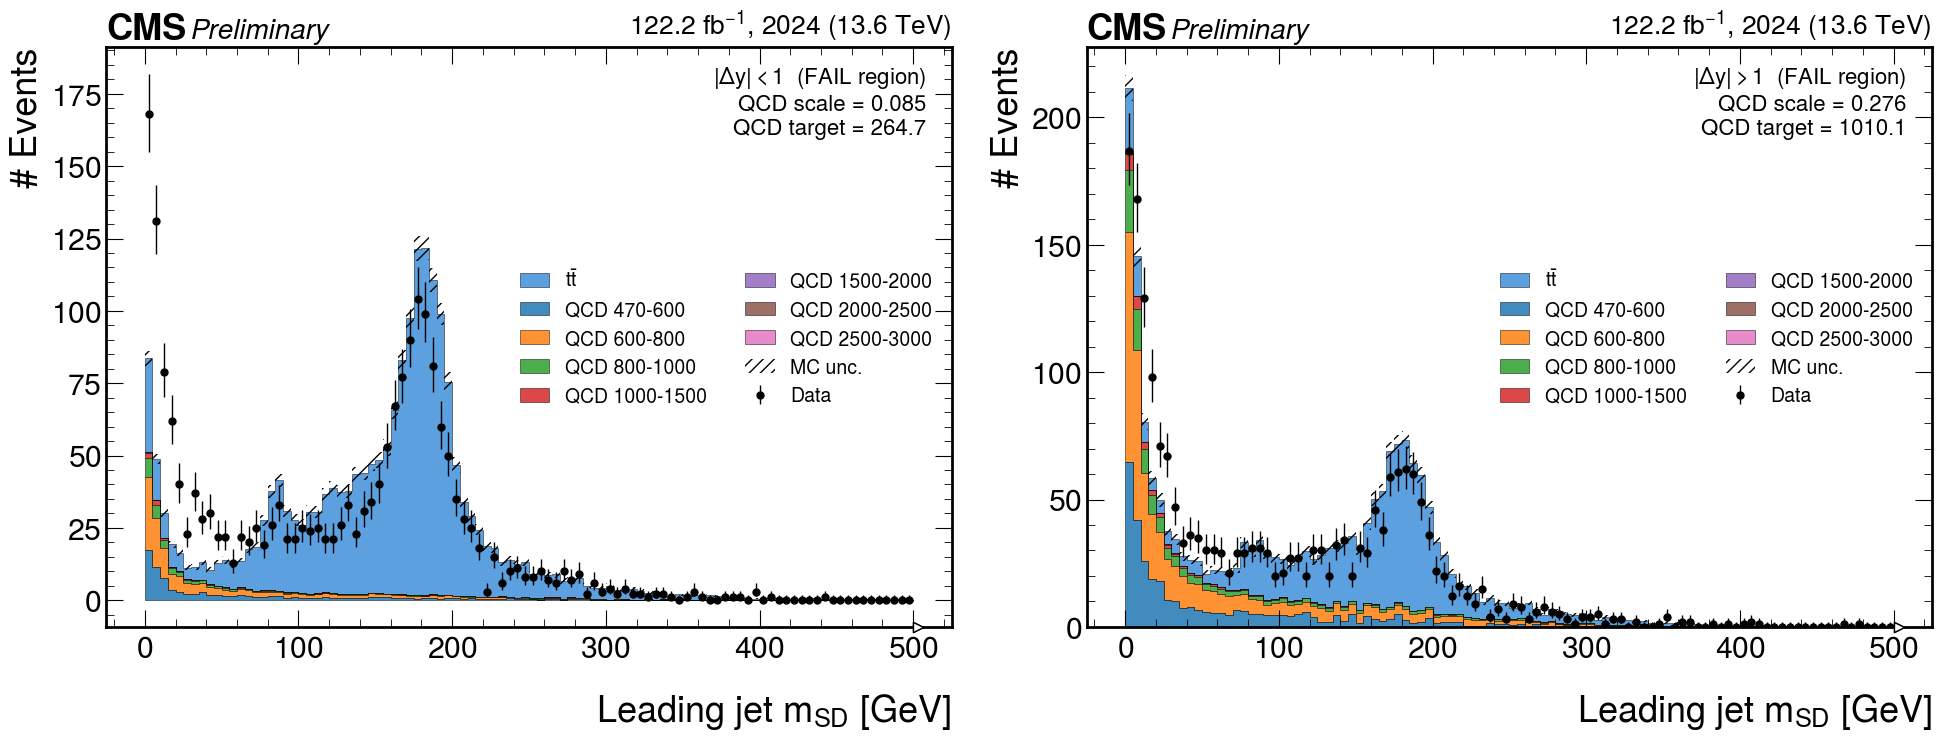

In [34]:
plot_specs = [
    ("ttbarmass", r"$m_{t\bar{t}}$ [GeV]"),
    ("jetmsd", r"Leading jet $m_{SD}$ [GeV]"),
    # ("jetmsd1", r"Subleading jet $m_{SD}$ [GeV]"),
    # ("jet0_pt", r"Leading jet $p_T$ [GeV]"),
    # ("jet0_eta", r"Leading jet $\eta$"),
    # ("jet0_phi", r"Leading jet $\phi$"),
    # ("jet0_rapidity", r"Leading jet rapidity"),
    # ("jet1_pt", r"Subleading jet $p_T$ [GeV]"),
    # ("jet1_eta", r"Subleading jet $\eta$"),
    # ("jet1_phi", r"Subleading jet $\phi$"),
    # ("jet1_rapidity", r"Subleading jet rapidity"),
    # ("jetdy", r"$\Delta y$"),
    # ("ht", r"$H_T$ [GeV]"),
]

# anacat IDs: 0=atcen, 1=atfwd, 2=2tcen, 3=2tfwd
cat_pairs = [
    (0, r"$|\Delta y| < 1$  (FAIL region)"),
    (1, r"$|\Delta y| > 1$  (FAIL region)"),
]

plot_density = False

for var, xlabel in plot_specs:
    fig, axes = plt.subplots(1, len(cat_pairs), figsize=(10 * len(cat_pairs), 8))

    for ax, (cat_id, cat_label) in zip(axes, cat_pairs):
        h_data = get_data_hist(var, cat_id)
        h_ttbar = get_hist(ttbar_output, var, cat_id)
        qcd_hists, qcd_scale, qcd_target = scaled_qcd_hists(var, cat_id, h_data, h_ttbar)

        stack_hists = qcd_hists + [h_ttbar]
        stack_labels = [label for label, _ in qcd_components] + [r"$t\bar{t}$"]
        stack_colors = qcd_colors(len(qcd_hists)) + [CMS_COLORS[0]]
        h_stack_total = sum_hists(stack_hists)

        hep.histplot(
            stack_hists,
            ax=ax,
            histtype="fill",
            stack=True,
            color=stack_colors,
            edgecolor="black",
            linewidth=0.4,
            label=stack_labels,
            density=plot_density,
            alpha=0.85,
            zorder=1,
        )
        draw_uncertainty_band(
            ax,
            h_stack_total,
            label="MC unc.",
            density=plot_density,
            zorder=2,
        )
        hep.histplot(
            h_data,
            ax=ax,
            histtype="errorbar",
            color="black",
            label="Data",
            density=plot_density,
            zorder=4,
        )

        hplot.quick_label(xlabel=xlabel, data=True, ax=ax)
        ax.text(
            0.97,
            0.97,
            f"{cat_label}\nQCD scale = {qcd_scale:.3g}\nQCD target = {qcd_target:.1f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=16,
        )
        ax.set_ylabel("A.U." if plot_density else "# Events")
        ax.set_xlabel(xlabel, labelpad=20)
        handles, labels = sort_legend_entries(*ax.get_legend_handles_labels())
        ax.legend(handles, labels, ncol=2, fontsize=14)

    plt.tight_layout()
    plt.show()

## Gen-level distributions (TTbar only)

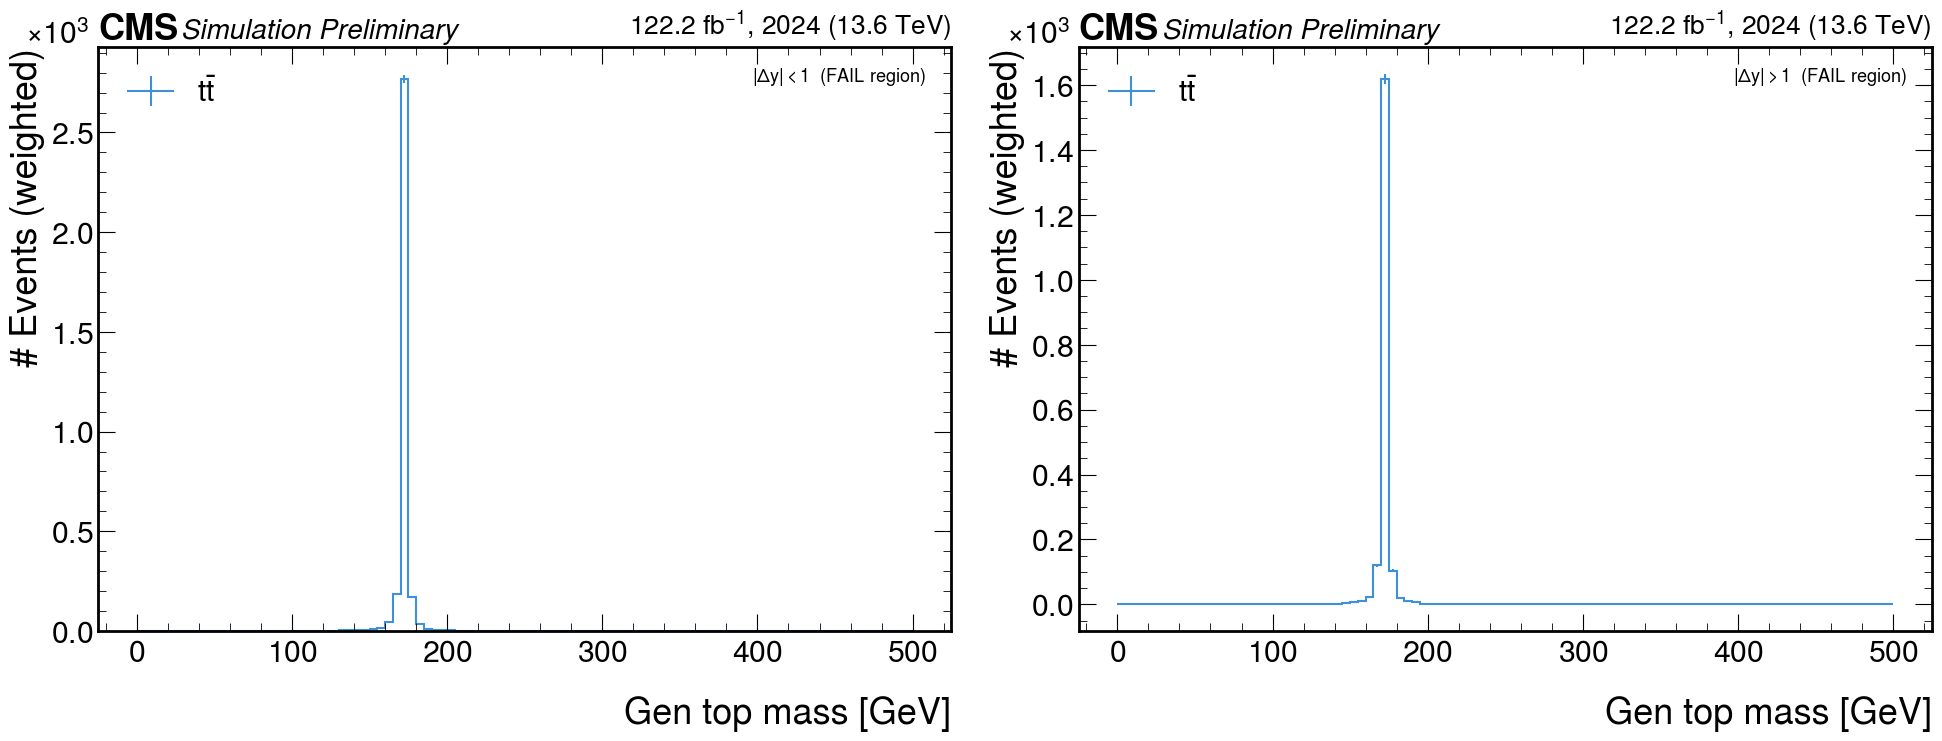

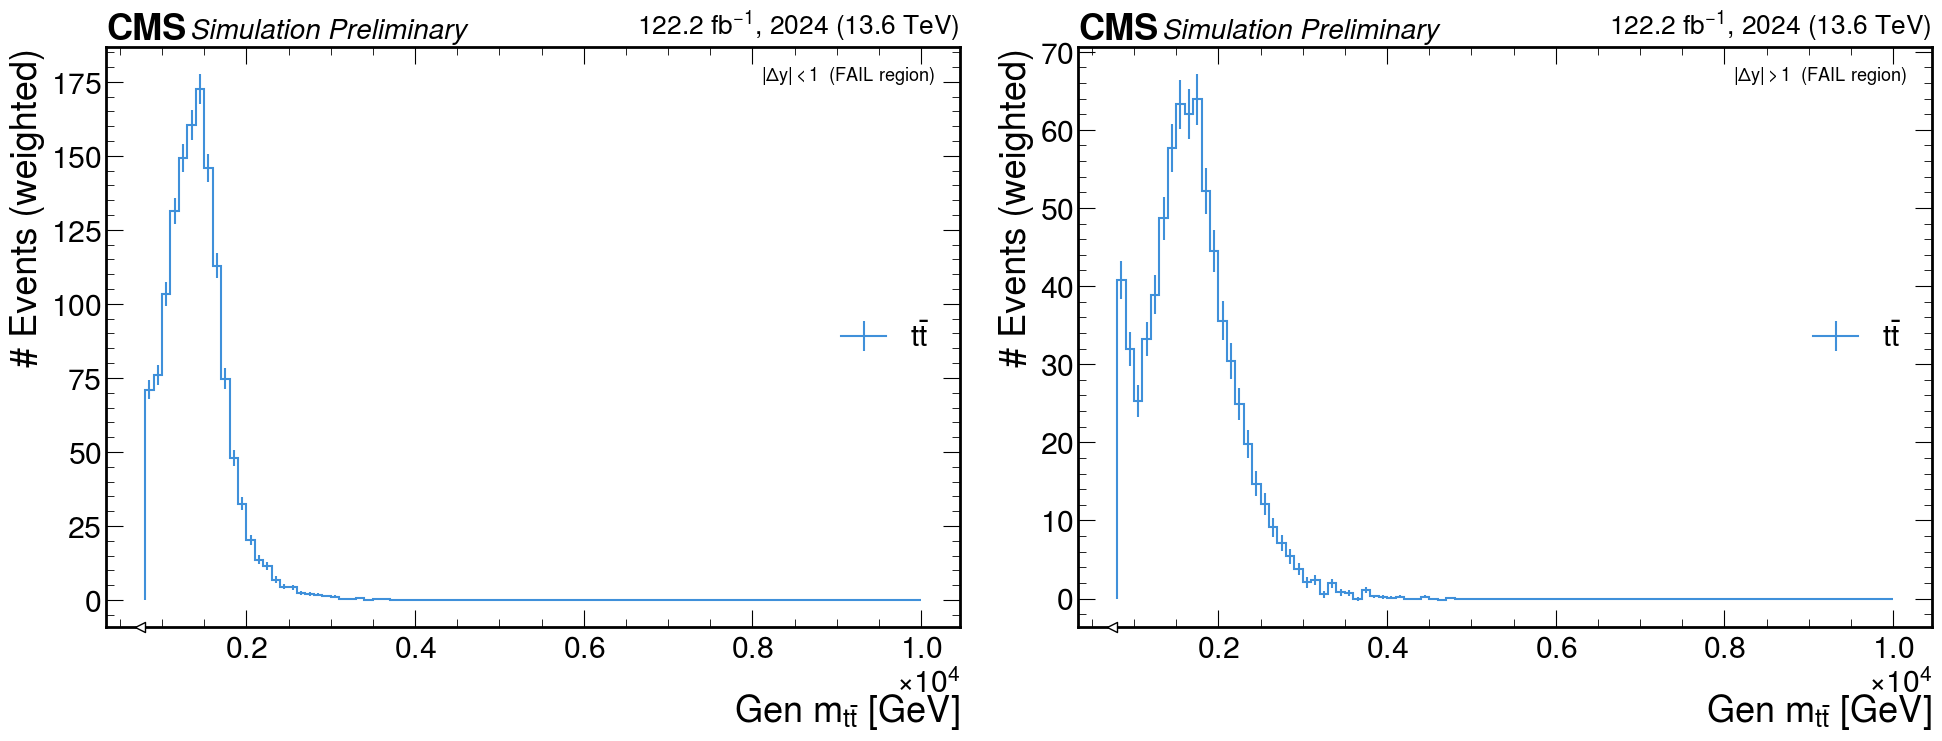

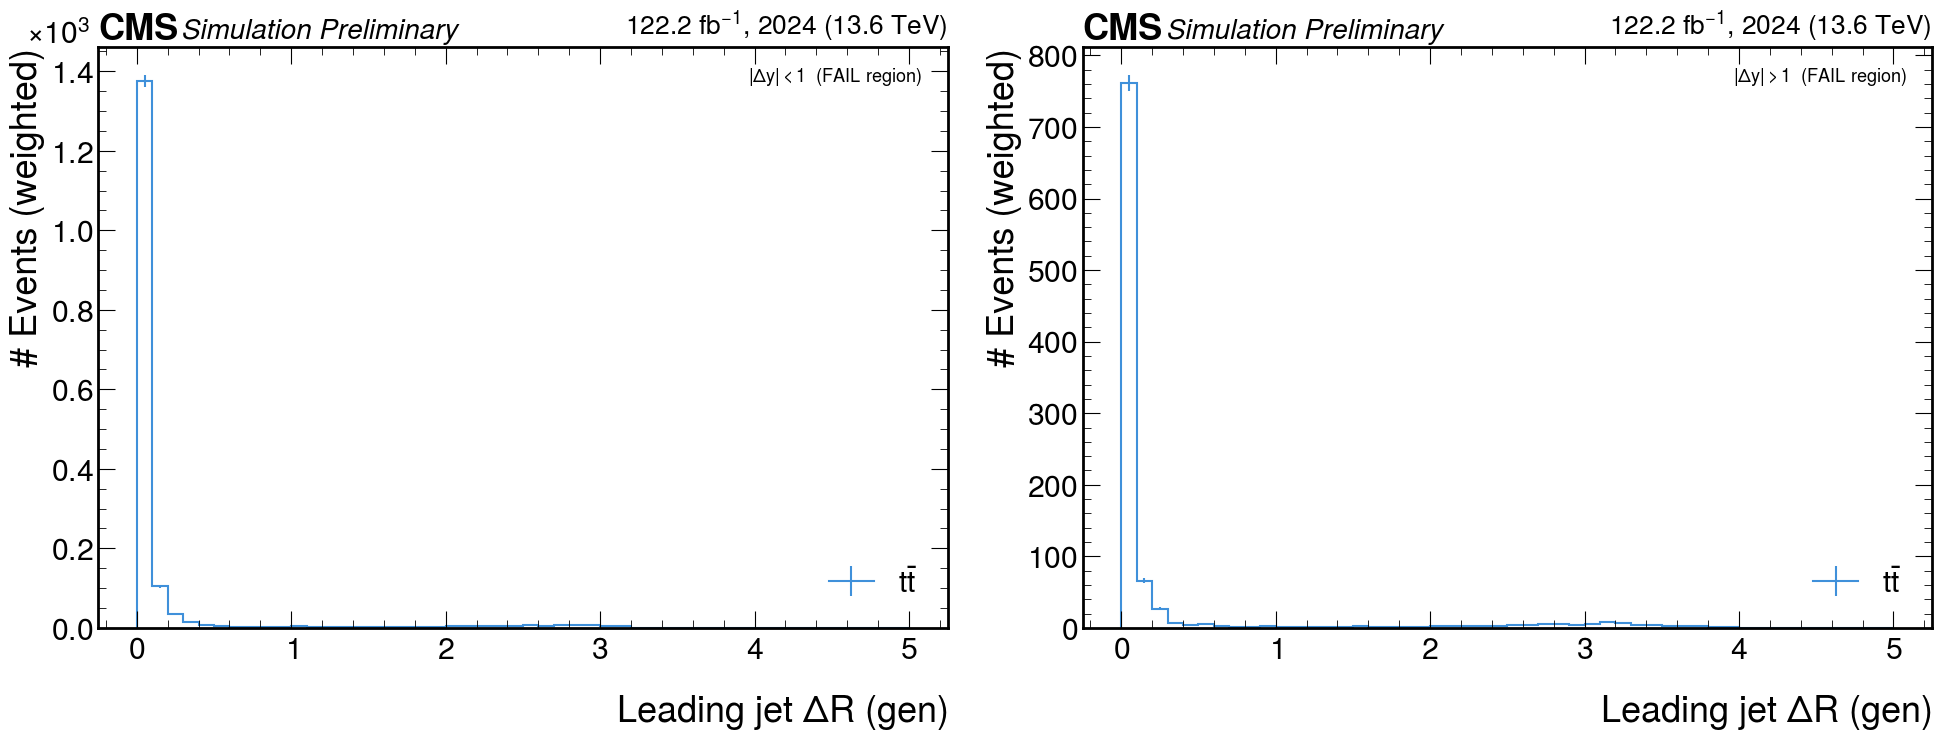

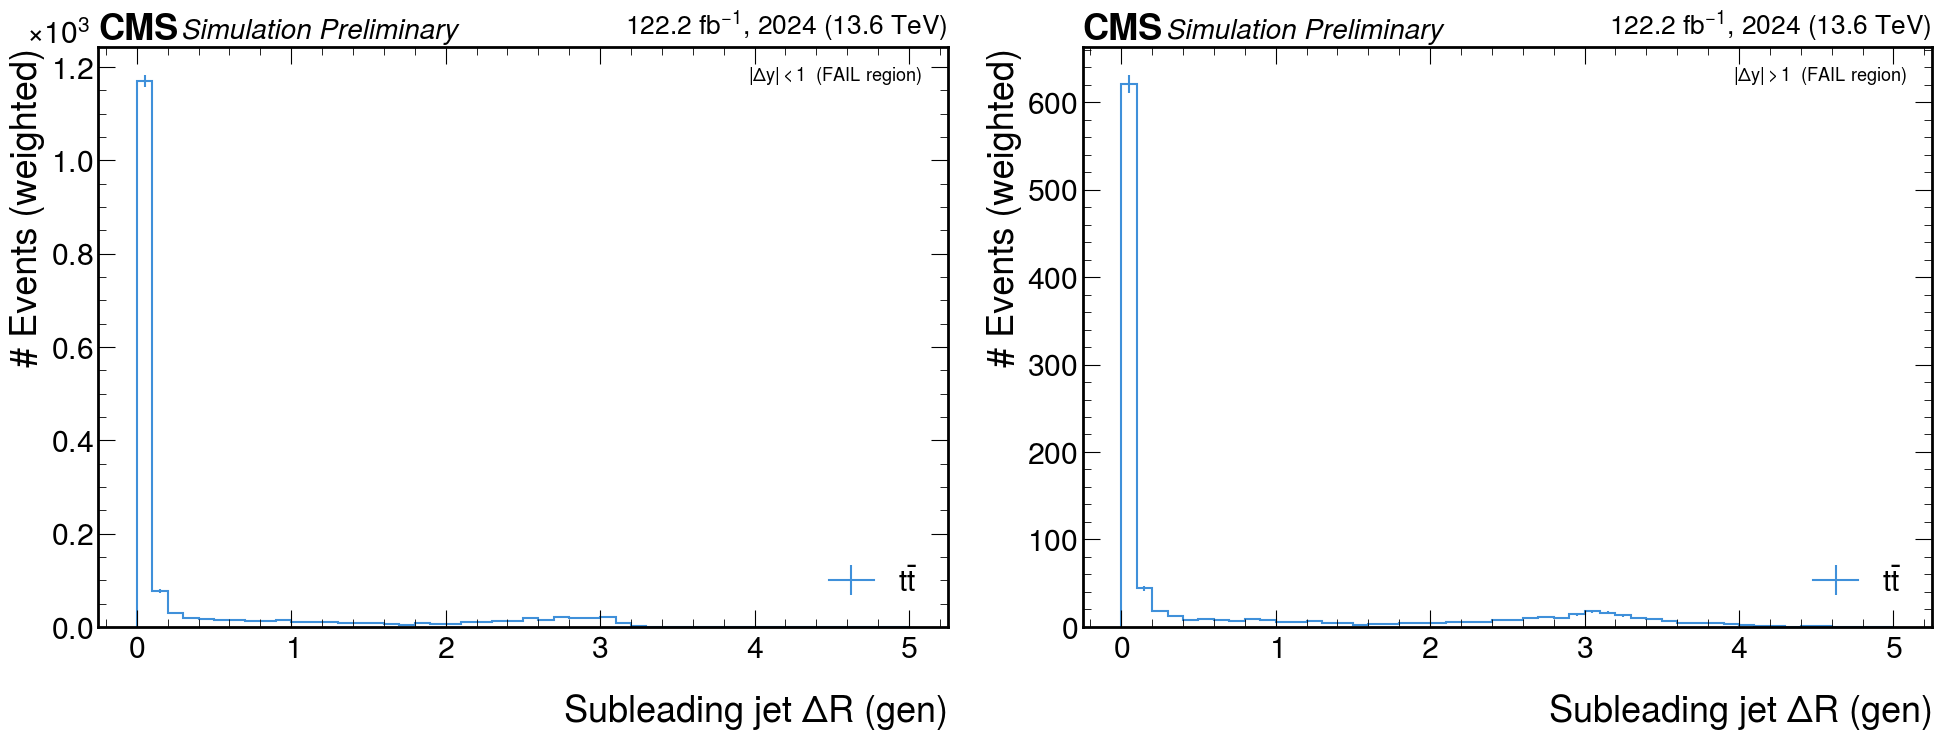

In [15]:
gen_specs = [
    ("gen_mt", r"Gen top mass [GeV]"),
    ("gen_mttbar", r"Gen $m_{t\bar{t}}$ [GeV]"),
    ("jet0_gen_dr", r"Leading jet $\Delta R$ (gen)"),
    ("jet1_gen_dr", r"Subleading jet $\Delta R$ (gen)"),
]

for var, xlabel in gen_specs:
    if var not in ttbar_output:
        continue

    fig, axes = plt.subplots(1, len(cat_pairs), figsize=(10 * len(cat_pairs), 8))

    for ax, (cat_id, cat_label) in zip(axes, cat_pairs):
        h = get_hist(ttbar_output, var, cat_id)

        hep.histplot(
            h,
            ax=ax,
            histtype="step",
            color=CMS_COLORS[0],
            label=r"$t\bar{t}$",
        )

        hplot.quick_label(xlabel=xlabel, data=False, ax=ax)
        ax.text(
            0.97,
            0.97,
            cat_label,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=13,
        )
        ax.set_ylabel("# Events (weighted)")
        ax.set_xlabel(xlabel, labelpad=20)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Cutflow

In [16]:
print("── TTbar ──")
print(ttbar_output["cutflow"])
print()

print("── QCD ──")
for label, output in qcd_components:
    print(f"  {label}")
    print(output["cutflow"])
    print()

── TTbar ──
defaultdict_accumulator(<class 'int'>, {'all events 1': 472535695, 'all events': 472535695, 'sumw': np.float32(1.6412679e+11), 'sumw2': np.float32(5.7941873e+13), 'trigger': 5484358, 'htCut': 1641207, 'metfilter': 1634078, 'jetkincut': 1596692, 'twoFatJets': 1303541, 'after_eventCut': 1303541, 'after_ttbarcandCuts': 1255056, 'atcen': 14635, 'atfwd': 8787, '2tcen': 107017, '2tfwd': 60037})

── QCD ──
  QCD 470-600
defaultdict_accumulator(<class 'int'>, {'all events 1': 77571658, 'all events': 77571568, 'sumw': np.float32(7.7571576e+07), 'sumw2': np.float32(7.7571576e+07), 'trigger': 46214400, 'htCut': 7281580, 'metfilter': 7258727, 'jetkincut': 7229761, 'twoFatJets': 6204384, 'after_eventCut': 6204384, 'after_ttbarcandCuts': 5965570, 'atcen': 1198, 'atfwd': 1414, '2tcen': 1110, '2tfwd': 1144})

  QCD 600-800
defaultdict_accumulator(<class 'int'>, {'all events 1': 79741832, 'all events': 79741832, 'sumw': np.float32(7.974184e+07), 'sumw2': np.float32(7.974184e+07), 'trigger':